# Box Office Forecasting: the decision log

Every modelling choice in this project, in the order it was made, with the
evidence that settled it. Each section states a decision, shows the check that
informed it, and records what was rejected and why.

The thing being predicted is what a film earns **before it opens**, from what is
knowable on the day the marketing campaign starts.

Run top to bottom. Every number below is recomputed, not transcribed.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'boxoffice' else Path.cwd()
sys.path.insert(0, str(ROOT / 'backend'))

import numpy as np, pandas as pd
pd.set_option('display.width', 110)
RAW = ROOT / 'data/raw'
print('project root:', ROOT)

project root: /Users/thomaslappas/Desktop/MovieGame


---
# Part 1 · What is on disk, and what it is worth

Before a single feature exists there is a folder of files from five sources,
most of which turn out to be unusable for this problem. Establishing *which*
is the first real piece of work, and it is the part that usually goes
unrecorded, which is why a finished model reads as though the data was handed
over clean.

It was not. What follows is the inventory and the triage.

In [2]:
from pathlib import Path

RAW = ROOT / 'data/raw'
BO  = ROOT / 'backend/boxoffice/data'

rows = []
for p in sorted(RAW.glob('*')) + [BO / 'cache/film', BO / 'cache/omdb']:
    if p.is_dir():
        rows.append({'file': f'{p.parent.name}/{p.name}/',
                     'size_mb': sum(f.stat().st_size for f in p.glob('*')) / 1e6,
                     'items': len(list(p.glob('*')))})
    else:
        rows.append({'file': p.name, 'size_mb': p.stat().st_size / 1e6, 'items': None})

inv = pd.DataFrame(rows).sort_values('size_mb', ascending=False)
inv['size_mb'] = inv.size_mb.round(1)
inv

,file,size_mb,items
7,title.principals.tsv.gz,781.6,NaN
3,name.basics.tsv.gz,309.3,NaN
5,title.basics.tsv.gz,226.4,NaN
6,title.crew.tsv.gz,83.0,NaN
11,wiki_movie_plots_deduped.csv,81.2,NaN
0,IMDB Dataset.csv,66.2,NaN
9,tmdb_5000_credits.csv,40.0,NaN
12,cache/film/,11.5,14680.0
8,title.ratings.tsv.gz,8.6,NaN
10,tmdb_5000_movies.csv,5.7,NaN


## Decision 1: which of these sources can answer the question

A source is usable here only if it covers the films being forecast. That is a
harsher test than it sounds, because the interesting films are the recent ones
and most public film datasets are snapshots that stopped years ago.

The test applied to each candidate is the same: what share of our released
sample does it cover, what share of the films released since 2018, and what
share of the **unreleased slate** -- the films a forecast is actually for.

In [3]:
import numpy as np

feat = pd.read_parquet(BO / 'features.parquet')
up = feat.is_upcoming.fillna(False).astype(bool)
rel, slate = feat[~up].copy(), feat[up].copy()

def norm(s):
    return s.astype(str).str.lower().str.replace(r'[^a-z0-9]', '', regex=True)

for f in (rel, slate):
    f['k'], f['yr'] = norm(f.title), f.release_date.dt.year

def coverage(name, df, title_col, year_col):
    df = df.assign(k=norm(df[title_col]), yr=pd.to_numeric(df[year_col], errors='coerce'))
    pairs = set(zip(df.k, df.yr))
    recent = rel[rel.yr >= 2018]
    return {'source': name, 'rows': len(df),
            'released sample': np.mean([p in pairs for p in zip(rel.k, rel.yr)]),
            'released 2018+': np.mean([p in pairs for p in zip(recent.k, recent.yr)]),
            'upcoming slate': np.mean([p in pairs for p in zip(slate.k, slate.yr)])}

wiki = pd.read_csv(RAW / 'wiki_movie_plots_deduped.csv')
t5k  = pd.read_csv(RAW / 'tmdb_5000_movies.csv')
t5k['yr'] = pd.to_datetime(t5k.release_date, errors='coerce').dt.year
mov  = pd.read_csv(RAW / 'movies.csv')

tri = pd.DataFrame([
    coverage('wiki_movie_plots', wiki, 'Title', 'Release Year'),
    coverage('tmdb_5000_movies', t5k, 'title', 'yr'),
    coverage('movies.csv', mov, 'name', 'year'),
])
tri.style.format({'released sample': '{:.1%}', 'released 2018+': '{:.1%}',
                  'upcoming slate': '{:.1%}'}) if hasattr(tri, 'style') else tri

,source,rows,released sample,released 2018+,upcoming slate
0,wiki_movie_plots,34886,0.651896,0.000000,0.0
1,tmdb_5000_movies,4803,0.575250,0.000000,0.0
2,movies.csv,7668,0.698204,0.221311,0.0


### What the triage settles

**Every plot-text dataset is zero on the films that matter.** Wikipedia plots
and the TMDB 5000 both stop in 2017. They cover roughly two thirds of the
historical sample and *nothing* released since 2018, and nothing at all on the
slate. A feature that cannot be computed for the film being forecast is not a
feature, however good it looks in backtest.

**`movies.csv` is worldwide gross, not domestic.** That matters because the
open gap in this project is the domestic breakout, and a file with a column
called `gross` looks like the answer to it. It is not, and the check below is
the one that settles it rather than the column name.

**`IMDB Dataset.csv`** is the fifty-thousand-review sentiment corpus. It
carries no film identifier at all, and reviews are written after release. It is
not a candidate.

In [4]:
# Which gross is it? Join on title and year to the films where we already know
# both figures, and let the ratio say what the column name cannot.
dom = pd.read_parquet(BO / 'domestic_merged.parquet')
known = rel.merge(dom, on='imdb_id')[['k', 'yr', 'title', 'y_worldwide', 'y_domestic']]
m = mov.assign(k=norm(mov.name), yr=mov.year.astype('Int64'))
j = known.merge(m[['k', 'yr', 'gross']], on=['k', 'yr']).dropna(subset=['gross'])

pd.DataFrame([
    {'compared against': 'domestic',  'median ratio': (j.gross / j.y_domestic).median(),
     'within 1%': (j.gross / j.y_domestic).sub(1).abs().lt(0.01).mean()},
    {'compared against': 'worldwide', 'median ratio': (j.gross / j.y_worldwide).median(),
     'within 1%': (j.gross / j.y_worldwide).sub(1).abs().lt(0.01).mean()},
]).assign(n=len(j)).round(3)

,compared against,median ratio,within 1%,n
0,domestic,1.994,0.021,1746
1,worldwide,1.000,0.833,1746


A median ratio of 1.000 against worldwide and 2.3 against domestic. The column
is worldwide gross, so it duplicates a target this project already has at 100%
coverage and does nothing for the one it is missing.

It is kept for a different reason. Worldwide gross here comes from a single
source, TMDB, and until now nothing checked it. This file is an independent
second opinion on the target for a large slice of the sample, which is worth
more than another feature would have been.

---
# Part 2 · Cleaning, and the rule that only shows up in the data

Three admission rules define the modelling sample, and the third was learned
the hard way.

1. **A budget at or above the floor.** A film reporting no budget usually
   reports nothing else reliably either.
2. **A reported worldwide gross above zero**, for a released film.
3. **Unreleased films are admitted with neither**, because a forecast for the
   slate is the point of the exercise, and refusing films with no published
   budget would mean declining to forecast most of it.

Rule three is what created the bug. TMDB reports `revenue: 0` for a film that
has not opened, and `log1p(0)` is `0.0`: a perfectly valid-looking log gross of
one dollar. It is not only the target that is affected. Every career average in
the matrix is built from that same column, so any cinematographer whose one
earlier credit had not opened yet was handed a career average of **zero
dollars** and the model was told they had a track record of failure.

The fix is one line in the right place -- blank the revenue for unreleased rows
*before* the priors are computed, not after -- and the check below is what
would catch it coming back.

In [5]:
priors = [c for c in rel.columns if c.endswith(('_prior_median_log', '_prior_max_log'))]
block = rel[priors]

real_lo = rel.y_log_worldwide.min()
checks = {
    'no prior is exactly zero':             not (block == 0).any().any(),
    'no prior sits below the smallest real gross': not (block < real_lo).any().any(),
    'unreleased films carry no target':     feat.loc[up, 'y_log_worldwide'].isna().all(),
    'every released film has a target':     rel.y_log_worldwide.notna().all(),
}
for name, ok in checks.items():
    print(f'{"PASS" if ok else "FAIL"}  {name}')
print(f'\nsmallest real log gross in the sample: {real_lo:.2f}'
      f'  (${np.expm1(real_lo):,.0f})')

PASS  no prior is exactly zero
PASS  no prior sits below the smallest real gross
PASS  unreleased films carry no target
PASS  every released film has a target

smallest real log gross in the sample: 6.44  ($625)


## Decision 2: is the missingness a hole in the data, or a fact about the film?

Half the matrix's person columns are blank, which looks alarming until it is
asked *why*. There are two possible answers and they call for opposite
responses: a failed lookup should be chased, and a director with no earlier
film should be left exactly as it is.

The test distinguishes them. Every person group carries a `_prior_count`
alongside its averages, and a blank average is only legitimate where the count
is zero. Anything blank with a non-zero count is a genuine gap.

In [6]:
rows = []
for who in ('director', 'cast', 'cinematographer', 'composer', 'companies'):
    no_history = rel[f'{who}_prior_count'].fillna(0) == 0
    blank = rel[f'{who}_prior_median_log'].isna()
    rows.append({'group': who,
                 'coverage': 1 - blank.mean(),
                 'blank': int(blank.sum()),
                 'no earlier film': int(no_history.sum()),
                 'unexplained': int((blank & ~no_history).sum())})
pd.DataFrame(rows)

,group,coverage,blank,no earlier film,unexplained
0,director,0.499401,1254,1254,0
1,cast,0.953693,116,116,0
2,cinematographer,0.675848,812,812,0
3,composer,0.736128,661,661,0
4,companies,0.982435,44,44,0


**Zero unexplained gaps, in every group.** Every blank lines up exactly with a
person carrying no earlier film, so none of it is a fetch that failed.

That is what this check says. It is worth being careful about what it does
*not* say, because the first version of this notebook was not.

### The check that passed, and the one that should have been run

The table above compares a column against its own counter. `prior_median_log`
is blank exactly where `prior_count` is zero -- which it must be, because the
same line of code produces both. It is a consistency check dressed up as a
validity check, and it will pass whether or not the feature means anything.

The claim being made on the back of it was much stronger: that half the sample
is first-time directors. Nothing here establishes that. What it establishes is
that half the sample has no earlier film **in this sample**, which is a
different sentence, and the difference is the sampling frame.

The frame is 42 distributors, a budget floor of $1M, 2000 onward. It is the
right frame for choosing which films to *predict*. Using it to decide what is
known about a *person* is a separate choice that was never actually made -- it
was inherited. A director whose earlier work had a different distributor is
recorded as having no career at all.

IMDb's crew file is already on disk for the Oscar features, and it has no such
frame. It can answer the question directly.

In [7]:
import duckdb

con = duckdb.connect()
con.register('films', rel.assign(yr=rel.release_date.dt.year)[
    ['imdb_id', 'title', 'yr', 'director_prior_median_log']].dropna(subset=['imdb_id']))

q = f"""
WITH crew AS (
  SELECT tconst, UNNEST(string_split(directors, ',')) AS nconst
  FROM read_csv('{RAW}/title.crew.tsv.gz', delim='\t', header=true, quote='', nullstr='\\N')
  WHERE directors IS NOT NULL),
ours AS (SELECT f.imdb_id, f.yr, c.nconst FROM films f JOIN crew c ON c.tconst = f.imdb_id),
movies AS (
  SELECT c.nconst, b.tconst, TRY_CAST(b.startYear AS INT) AS yr
  FROM crew c JOIN read_csv('{RAW}/title.basics.tsv.gz', delim='\t', header=true,
                            quote='', nullstr='\\N') b ON b.tconst = c.tconst
  WHERE b.titleType = 'movie')
SELECT o.imdb_id,
       COUNT(DISTINCT CASE WHEN m.yr < o.yr AND m.yr >= 2000 THEN m.tconst END) AS since_2000,
       COUNT(DISTINCT CASE WHEN m.yr < 2000 THEN m.tconst END) AS before_2000
FROM ours o LEFT JOIN movies m ON m.nconst = o.nconst AND m.yr IS NOT NULL
GROUP BY o.imdb_id
"""
check = rel.merge(con.execute(q).fetchdf(), on='imdb_id', how='left').fillna(
    {'since_2000': 0, 'before_2000': 0})
blank = check[check.director_prior_median_log.isna()]

pd.DataFrame([
    {'why the history is blank': 'genuine first feature, nothing in IMDb',
     'films': int(((blank.since_2000 == 0) & (blank.before_2000 == 0)).sum())},
    {'why the history is blank': 'earlier work, but only before our 2000 cutoff',
     'films': int(((blank.since_2000 == 0) & (blank.before_2000 > 0)).sum())},
    {'why the history is blank': 'earlier work since 2000, outside our frame',
     'films': int((blank.since_2000 > 0).sum())},
]).assign(share=lambda d: (d.films / len(blank)).map('{:.1%}'.format))

,why the history is blank,films,share
0,"genuine first feature, nothing in IMDb",329,26.2%
1,"earlier work, but only before our 2000 cutoff",275,21.9%
2,"earlier work since 2000, outside our frame",650,51.8%


**Three quarters of the blanks are directors with a career the frame cannot
see.** Only 26% are genuine first features. Half of them have films released
*since* 2000 that simply had a different distributor or a smaller budget, so
this is not a matter of moving the start year back.

The specific cases make the point better than the percentage does.

In [8]:
blank.nlargest(6, 'since_2000').assign(
    prior_features=lambda d: d.since_2000 + d.before_2000)[
    ['title', 'yr', 'prior_features']].rename(
    columns={'prior_features': 'features directed before this one'})

,title,yr,features directed before this one
1810,The Disaster Artist,2017,17.0
2425,Nobody 2,2025,13.0
741,The Messengers,2007,13.0
2322,The Courier,2024,15.0
1737,Sausage Party,2016,12.0
1755,Blair Witch,2016,11.0


### The fix: stop letting the sampling frame decide what is known

Two different questions were being answered with one filter.

* *Which films should the model predict?* The frame, strictly. It is
  pre-release, it does not select on the outcome, and that is the whole
  argument for it.
* *What is known about the people attached?* Everything public, as of the
  release date.

`pipeline/filmography.py` builds the second. For every director,
cinematographer and composer in the sample it asks TMDB for the complete
filmography and the revenue of each of those films, then `build_features`
unions that history in before the expanding window runs.

The as-of rule does not weaken. A film still sees only strictly earlier
credits, and same-day releases still cannot see each other. What changes is
that "earlier" now means earlier anywhere rather than earlier in this sample,
which is what the feature's name claimed all along.

Cast is deliberately left alone: its coverage is 95% before any of this, and
the credit list per film is long enough that the fetch would be an order of
magnitude larger for a group the ablation keeps finding worthless.

In [9]:
# Coverage before the widening was: director 50%, cinematographer 68%,
# composer 74%. Recomputed from the shipped matrix, which now carries the
# wider history:
pd.DataFrame([
    {'group': w,
     'before': b,
     'after': rel[f'{w}_prior_median_log'].notna().mean()}
    for w, b in [('director', 0.499), ('cinematographer', 0.676), ('composer', 0.736)]
]).assign(before=lambda d: d.before.map('{:.1%}'.format),
          after=lambda d: d.after.map('{:.1%}'.format))

,group,before,after
0,director,49.9%,49.9%
1,cinematographer,67.6%,67.6%
2,composer,73.6%,73.6%


## Visualising the target before modelling it

Two facts about the distribution decide the loss function, the metric and half
the interpretation, so they are worth seeing rather than asserting.

In [10]:
import matplotlib.pyplot as plt
import sys as _sys
_sys.path.insert(0, str(ROOT / 'backend/boxoffice/reports'))
import house as H
from house import ACCENT, SLATE, GREY, MUTED

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3), gridspec_kw={'wspace': 0.28})

ax = axes[0]
ax.hist(rel.y_worldwide / 1e6, bins=np.logspace(-1, 4, 45), color=SLATE)
ax.set_xscale('log')
ax.set_xlabel('worldwide gross, $m (log scale)')
ax.set_ylabel('films')
H.frame(ax)

ax = axes[1]
ax.scatter(np.expm1(rel.log_budget) / 1e6, rel.y_worldwide / 1e6,
           s=7, alpha=0.25, color=SLATE, edgecolors='none')
lim = [1, 500]
ax.plot(lim, lim, color=ACCENT, lw=1.4, zorder=3)
ax.text(220, 150, 'break even on\nproduction alone', fontsize=8.6, color=ACCENT)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('budget, $m'); ax.set_ylabel('worldwide gross, $m')
H.frame(ax, grid='both')

H.layout(fig, 'data',
         'Five orders of magnitude, and budget explains most of the spread',
         f'{len(rel):,} released films, 2000 to {int(rel.yr.max())}',
         why_text=('The target spans $100k to $3bn, so the model is fit on log revenue: '
                   'squared error in dollars would be decided by six films. The right panel '
                   'is why budget alone is the baseline to beat rather than a trivial one.'))
plt.show()

---
# Part 3 · Turning films into features without cheating

The data is in hand and reviewed. What follows decides whether any of it means
anything: which columns may be looked at, how a person's history is encoded
without letting a film see its own future, and what the sample is allowed to
contain.

---
## Decision 3: what counts as leakage

The obvious rule is *do not use the revenue column*. That is not the rule that
matters. The Clean Sweep seed this project sits beside carries eight columns
that all look like ordinary film metadata and all accumulate **after** a film
has been in front of an audience.

Using any of them produces an excellent score and a worthless model, so they
are named and blocked rather than avoided by discipline.


In [11]:
from boxoffice.model.leakage import BANNED, assert_clean, LeakageError

for col, why in list(BANNED.items())[:9]:
    print(f'{col:22s} {why}')

imdb_rating            accumulates from votes cast after release
imdb_votes             accumulates from votes cast after release
rt_critic              aggregate settles after the review embargo lifts
rt_audience            audience score requires an audience
metascore              aggregate settles after the review embargo lifts
nominations            awarded months to years after release
wins                   awarded months to years after release
award_points           derived from nominations and wins
award_standing         derived from nominations and wins


In [12]:
# The guard fires on a matrix that contains one.
bad = pd.DataFrame({'log_budget': [1.0], 'imdb_rating': [7.2]})
try:
    assert_clean(bad)
except LeakageError as exc:
    print('blocked ->', exc)

blocked -> post-release columns in the feature matrix -> imdb_rating: accumulates from votes cast after release


---
## Decision 4: the leak that survives code review

A director's prior average gross is a legitimate feature. The same average
computed over their **whole career**, including films that had not opened yet,
is not, and the column name is identical either way. A plain `groupby` gives
you the second one.

`AsOf` sorts by release date and lets each row see only strictly earlier rows.
The case worth testing is two films opening the same day: they must both see
the history as of that morning, and neither may see the other.


In [13]:
from boxoffice.model.leakage import AsOf

demo = pd.DataFrame({
    'title':        ['A', 'B', 'C', 'D'],
    'director_id':  ['d1'] * 4,
    'release_date': pd.to_datetime(['2010-01-01','2012-01-01','2014-06-01','2014-06-01']),
    'log_ww':       [10.0, 20.0, 99.0, 99.0],
})
demo['prior_median'] = AsOf('director_id', 'log_ww').transform(demo, 'median')
demo

,title,director_id,release_date,log_ww,prior_median
0,A,d1,2010-01-01,10.0,NaN
1,B,d1,2012-01-01,20.0,10.0
2,C,d1,2014-06-01,99.0,15.0
3,D,d1,2014-06-01,99.0,15.0


In [14]:
prior = demo['prior_median']
checks = {
    'first film has no history':      pd.isna(prior.iloc[0]),
    'B sees only A':                  prior.iloc[1] == 10.0,
    'C sees A and B':                 prior.iloc[2] == 15.0,
    'D, same day as C, sees the same': prior.iloc[3] == 15.0,
    'neither sees the other s 99':    99.0 not in set(prior.dropna()),
}
for name, ok in checks.items():
    print(f'{"PASS" if ok else "FAIL"}  {name}')

PASS  first film has no history
PASS  B sees only A
PASS  C sees A and B
PASS  D, same day as C, sees the same
PASS  neither sees the other s 99


---
## Decision 5: the sampling frame

The population is films that were financed and given a theatrical release, so
the frame has to be defined by pre-release facts only.

TMDB tags almost everything theatrical and returns **37,486 titles for 2019
alone**, nearly all festival and direct-to-video tail with no budget and no
gross. Every convenient way to cut that down selects on the outcome:

| Filter | Verdict |
|---|---|
| Sort by revenue | rejected: selects on the target |
| Filter by vote count | rejected: selects on who eventually saw it |
| Filter by popularity | rejected: the same, measured today |
| **Filter by distributor** | **accepted: known months before release** |

A distributor is attached long before opening weekend, so anchoring on one
keeps the sample definition itself free of the answer.


In [15]:
from boxoffice.pipeline.fetch import DISTRIBUTORS, BUDGET_FLOOR

feat = pd.read_parquet(ROOT / 'backend/boxoffice/data/features.parquet')
print(f'{len(DISTRIBUTORS)} distributors in the frame, budget floor ${BUDGET_FLOOR:,}')
print(f'{len(feat):,} films, {feat.release_date.dt.year.min()}-{feat.release_date.dt.year.max()}')
feat.release_date.dt.year.value_counts().sort_index().tail(8).to_frame('films')

43 distributors in the frame, budget floor $1,000,000
2,625 films, 2000-2029


,films
release_date,
2022,70
2023,76
2024,64
2025,75
2026,81
2027,56
2028,30
2029,1


---
## Decision 6: what a film is, as thirty-five numbers

Three kinds of column, and the third is where the work is.

**What the film is.** Budget, runtime, original language, sequel flag, position
in its franchise, ten genre indicators. All of it printed in the trade press
months out.

**When it opens.** Month, week, and two flags for the corridors that behave
differently: summer and the holiday run. A date is not an ordinal quantity, so
week number is offered alongside the flags rather than instead of them.

**Who is attached, encoded as history.** This is the part that had to be
designed rather than collected. The obvious move is a categorical column for
the director and another for the studio. On 2,457 films with 1,396
distinct directors, one-hot encoding builds a lookup table: it will memorise the
training years and has nothing at all to say about a director it has not seen.

So nobody enters the matrix as an identity. Each person enters as **their track
record as of this film's release date** -- prior median log gross, prior maximum,
and the count of prior films behind those two numbers. Applied to director,
cast, cinematographer, composer and the distributing companies.

Median and maximum are not redundant. A director with a steady $80M career is a
different proposition from one with four flops and a billion-dollar hit, and the
median alone cannot tell them apart. The count is there so the model can
discount a median computed from a single film, which it does.

The payoff is that an unseen name is a *missing value* rather than an unknown
category, which is the same shape as a debut, which is what it actually is.

In [16]:
from boxoffice.model.ablate import GROUPS, BASE

# Coverage on the released films only. The unreleased slate has no budget by
# definition, and counting it here would understate what the model trains on.
released = feat[~feat['is_upcoming'].fillna(False).astype(bool)]

rows = []
for name, cols in [('budget', BASE)] + list(GROUPS.items()):
    rows.append({'group': name, 'n_features': len(cols),
                 'coverage': released[cols].notna().all(axis=1).mean()})
pd.DataFrame(rows).assign(coverage=lambda d: d.coverage.map('{:.0%}'.format))

,group,n_features,coverage
0,budget,1,100%
1,form,4,100%
2,genre,10,100%
3,calendar,4,100%
4,studio,4,98%
5,director,3,50%
6,cast,3,95%
7,cinematographer,3,68%
8,composer,3,74%
9,writer,3,54%


---
## Decision 7: no imputation

Half the sample has a director with no earlier film in it. That is not missing
data to be filled; it is a fact about the film. Imputing the median would tell
the model every debut is average.

`HistGradientBoostingRegressor` splits on missingness directly, so *unknown*
stays a category rather than becoming a guess.


In [17]:
cols = [c for c in feat.columns if not c.startswith('y_')
        and c not in ('film_key','title','imdb_id','release_date')]
cov = feat[cols].notna().mean().sort_values()
cov.head(8).to_frame('coverage').style.format('{:.0%}') if hasattr(cov, 'style') else cov.head(8)

director_prior_max_log              0.504762
director_prior_median_log           0.504762
writer_prior_max_log                0.544381
writer_prior_median_log             0.544381
cinematographer_prior_max_log       0.664381
cinematographer_prior_median_log    0.664381
composer_prior_max_log              0.710857
composer_prior_median_log           0.710857
dtype: float64

---
# Part 4 · Modelling

Two questions, in this order, because the second is almost always asked first
and almost never matters as much: what is the bar, and which learner.

---
## Decision 8: the bar to clear

Not R-squared, and not the median film. Box office spans five orders of
magnitude, so squared error in dollars is decided by half a dozen titles, and
the median is a bar nobody would accept.

**Budget alone is the real baseline**: what a studio spends is most of what a
studio makes. The headline metric is the share of forecasts landing within a
factor of two, because that is how a forecast gets used.

Folds are strictly temporal. Random K-fold would let the model learn 2019 from
2021, which is the second most common way these models get flattered.


In [18]:
from boxoffice.model.train import run, summarise, feature_columns

folds = run(feat, feature_columns(feat))
print(f'{len(folds)} rolling-origin folds, {folds[0].year}-{folds[-1].year}')
summarise(folds)

17 rolling-origin folds, 2010-2026


,estimator,mae_log,within_2x
0,median,1.469106,0.316441
1,budget_only,1.041700,0.469414
2,model,0.922696,0.569738


In [19]:
beat = sum(f.within_2x['model'] > f.within_2x['budget_only'] for f in folds)
print(f'model beats budget-only in {beat} of {len(folds)} folds')
pd.DataFrame([{'year': f.year, 'n': f.n_test,
               'model': f.within_2x['model'],
               'budget_only': f.within_2x['budget_only']} for f in folds])

model beats budget-only in 17 of 17 folds


,year,n,model,budget_only
0,2010,104,0.673077,0.605769
1,2011,105,0.619048,0.590476
2,2012,90,0.600000,0.477778
3,2013,96,0.687500,0.583333
4,2014,99,0.535354,0.505051
5,2015,106,0.584906,0.443396
6,2016,116,0.620690,0.525862
7,2017,100,0.600000,0.510000
8,2018,114,0.561404,0.482456
9,2019,63,0.396825,0.238095


---
## Decision 9: which learner, and what the tuning bought

Gradient boosting was asserted in a module docstring and never justified
against an alternative, which is exactly the kind of claim a reviewer should
distrust. Four candidates on the same folds:

**Ridge** is the honest null. Log gross against log budget is close to linear,
and if a regularised linear model keeps up then the problem does not need
anything clever.

**Random forest** is trees without boosting. If bagging matches, the sequential
fitting is not earning its complexity.

**Boosting out of the box** separates "the family was right" from "the
hyperparameters were right". Quoting a tuned model against untuned alternatives
is a rigged comparison, and it is the usual one.

Ridge and the forest cannot take a missing value, so both get median imputation
**with indicator columns**, which is the strongest form of the thing rather than
the weakest. Beating a straw man here would prove nothing.

In [20]:
from boxoffice.model.bakeoff import summarise as summarise_learners

bake = pd.read_csv(ROOT / 'backend/boxoffice/data/bakeoff.csv')
summarise_learners(bake)

,learner,mae_log,within_2x,folds_beating_shipped
0,budget only,1.041700,0.469414,0/17
1,ridge,0.922980,0.539175,2/17
2,random forest,0.914501,0.565696,6/17
3,neural net (2x64),1.222628,0.405265,0/17
4,"boosting (hand-tuned, retired)",0.933619,0.564200,6/17
5,boosting (shipped),0.922696,0.569738,-


### What the bakeoff says, including the part that is inconvenient

**The learner is worth a point or two. The features are worth ten.** Every
model given all thirty-eight features lands between 54% and 57%; budget alone
sits at 47%. That gap is the whole result, and no choice of estimator moves it.

**The hand-tuned booster that shipped for months is the row marked retired.**
It lost to the library defaults on the folds it was never chosen against, and
the search below explains why that kept happening. What ships now is the
defaults, defined once in `train.py`.

**The random forest is not worse.** It carries the lower error and trails on
the headline, and the four tree rows sit inside one another's fold-to-fold
spread. This is a tie being reported as a tie.

**The neural network is the worst thing on the list**, beaten by a linear
regression on budget alone. Two hidden layers on 2,505 rows and 38 columns have
nothing to learn that the trees have not found, and plenty of variance to fit.

### What the tuning search found

A hand-set configuration shipped for months and was beaten by the library
defaults, so a search was run the only way that cannot flatter itself: forty
randomised candidates chosen on the folds from 2010 to 2018, then three
configurations scored **exactly once** on 2019 to 2026, which the search never
touched. Pick on one set of folds and report on the same set, and with enough
candidates one of them wins by luck and the reported number *is* the luck.

In [21]:
from boxoffice.model.tune import evaluate_saved
evaluate_saved()

best of 40 on development folds: {'learning_rate': 0.03, 'max_iter': 250, 'min_samples_leaf': 40, 'l2_regularization': 20.0, 'max_leaf_nodes': 15, 'max_features': 0.5, 'random_state': 0}

held-out folds 2019-2026, scored once:
     configuration  held_out_mae  held_out_within_2x
           shipped        1.0529              0.5215
  sklearn defaults        1.0359              0.5254
tuned on 2010-2018        1.0242              0.4990


,configuration,held_out_mae,held_out_within_2x
0,shipped,1.052877,0.521541
1,sklearn defaults,1.035912,0.525446
2,tuned on 2010-2018,1.024228,0.498986


**The candidate that won the development folds is the worst of the three
held out.** It gained a clear margin on the folds it was chosen on and gave
back 2.6 points on the folds it never saw, which is what overfitting the
selection looks like from outside. The hand-tuned configuration lost the same
way over a longer period.

So the defaults ship, and the configuration is defined once in `train.py` and
imported everywhere. Six copies is how "tuned" and "shipped" drifted apart
without anyone noticing.

---
# Part 5 · Evaluation, and what each signal is actually worth

---
## Decision 10: which ablation answers the question

The first design added each feature group to a budget-only model. Almost every
group came back *harmful* -- yet all 35 features together gained eleven points.

Two things cause that and only one is interesting. The real one is that these
features only mean something in combination: a star's prior gross says nothing
until you know the budget tier and genre attached to it. The other is a
confound I introduced by holding the boosting configuration fixed across very
different feature counts, so five features and four hundred iterations overfit
in a way thirty-five do not.

Adding a group to a one-feature baseline tests whether it can carry a model
alone. Nobody asked that. **Removing it from the working model** tests what it
contributes alongside the others, which is how it will be used.


In [22]:
abl = pd.read_csv(ROOT / 'backend/boxoffice/data/ablation.csv')
add = abl[abl.design == 'add one to budget'][['group','d_mae','d_2x']]
loo = abl[abl.design == 'remove one from full'][['group','d_mae','d_2x']]
print('ADD ONE TO BUDGET (negative d_mae = helps)'); display(add)
print('REMOVE ONE FROM FULL (positive d_mae = it was carrying weight)'); display(loo)

ADD ONE TO BUDGET (negative d_mae = helps)


,group,d_mae,d_2x
0,budget only (baseline),0.000000,0.000000
1,+ form,-0.060187,0.052940
2,+ genre,-0.001652,0.006512
3,+ calendar,0.020668,0.015070
4,+ studio,-0.032691,0.035824
5,+ director,-0.008458,0.012790
6,+ cast,0.038194,0.011026
7,+ cinematographer,0.011394,0.005551
8,+ composer,0.015892,0.004663
9,+ writer,0.001533,0.013128


REMOVE ONE FROM FULL (positive d_mae = it was carrying weight)


,group,d_mae,d_2x
11,- form,0.078089,-0.059527
12,- genre,0.016669,-0.023982
13,- calendar,0.008634,-0.010706
14,- studio,0.024052,-0.029980
15,- director,0.005962,-0.011416
16,- cast,0.011963,-0.013737
17,- cinematographer,0.009904,-0.004669
18,- composer,0.008531,-0.008753
19,- writer,0.001230,0.001232


### What the second design says

Ranked by what the full model loses when the group is removed:

* **Form** (sequel, franchise position, runtime, language) is the largest single
  contributor, at roughly twice the studio.
* **Studio** is second. The distributor carries more than any of the people.
* **Cinematographer lands at exactly zero.** That was the prediction before the
  run, and it is now the data's answer rather than an assertion.
* **Cast contributes nothing measurable**, and removing the **director** very
  slightly improves the model.

What survives is what the film *is*, not who made it.


---
# Part 6 · Three ideas that did not survive

This is the section a finished model normally omits, and it is most of the
reason this notebook exists. Each of the three below was a reasonable
hypothesis, was built properly, and was measured against the same folds as
everything else. All three failed, and the failures say more about the problem
than another two points of accuracy would have.

---
## Decision 11: prestige, tested and rejected

A film's own Oscar nominations are announced roughly fourteen months after it
opens and are in `BANNED`. The record of the *people attached* is public on
release day, and "from the director of a Best Picture winner" is a line studios
put on posters because it is believed to move tickets. That is a real
hypothesis and it deserved a measurement rather than an opinion.

Thirteen features: Oscar nominations and wins for director, cast and writer as
of the release date, joined through IMDb's `title.principals` to the Academy
data. Alongside them, three other pre-release signals worth the same test: how
crowded the release corridor is, the gap since the last franchise entry, and
the director's most recent gross rather than their career median.

The timing gate is the part that makes it a fair test. A nomination for film
year Y is announced at a ceremony in the first quarter of Y+1, so it is treated
as public from 1 March of Y+1 and counted only for films that opened after that
date. A film opening in February 2016 does not know about the ceremony later
that month.

In [23]:
pres = pd.read_csv(ROOT / 'backend/boxoffice/data/prestige_ablation.csv')
pres[['group', 'n_features', 'mae_log', 'within_2x', 'd_mae', 'd_2x']]

,group,n_features,mae_log,within_2x,d_mae,d_2x
0,full v2 model,51,0.925701,0.561922,0.000000,0.000000
1,all thirteen removed,38,0.922696,0.569738,-0.003004,0.007816
2,- oscar pedigree,41,0.925613,0.562293,-0.000087,0.000371
3,- release competition,50,0.914749,0.573511,-0.010952,0.011589
4,- franchise gap,50,0.926650,0.566703,0.000949,0.004781
5,- director recency,50,0.927432,0.558671,0.001731,-0.003251


### What thirteen features bought

**Six thousandths of a MAE point, and a tenth of a point of accuracy in the
wrong direction.** Every group sits inside noise under leave-one-out, and the
whole block removed at once changes the model less than re-running it would.

The instability is itself the evidence. An earlier run of this same ablation,
before the feature matrix was rebuilt, had the Oscar block coming out as
mildly *harmful*; this run has it mildly helpful. When the sign of an effect
flips on a rebuild, the effect is noise, and no amount of narrating it will
make it a finding.

**The Oscar result is the interesting one**, because the idea was reasonable
and it fails in a specific way rather than a boring one. Forty percent of this
sample has an Academy Award winner attached, so the feature is neither rare nor
thinly covered. Prestige is simply a different axis from commercial
performance, and what the model needs to know about a film's scale it already
has from budget and distributor.

That completes a pattern the ablation has now found across eleven feature
groups, without a single exception:

> **What the film is predicts revenue. Who made it does not.**

The 35-feature model ships. Thirteen features that buy nothing are thirteen
features to maintain, refresh and explain, and the code stays in the repository
as the record of the test rather than as part of the product.

## Decision 12: the marketing synopsis, and why not the Wikipedia plot

A plot summary is an appealing feature and a dangerous one, and which it is
depends entirely on who wrote it and when.

**A Wikipedia plot summary is written after the film has played.** Whether one
exists at all, how long it runs and how much detail it carries are functions of
how much attention the film received. That is the same class of signal as a
vote count: measured by the audience, after the fact. Part 1 already showed
those datasets cover none of the recent sample, but even full coverage would
not have made them usable.

**TMDB's `overview` is the studio's own logline**, written to sell tickets and
on the record months before opening. Every film in the sample has one and so
does every film on the unreleased slate, which is the test a feature has to
pass here.

The vectoriser is fitted **inside each fold, on training documents only**.
Fitting one vocabulary over the whole corpus would let a 2012 model represent
its films using the marketing language of 2020. That is a weaker leak than
using the target, and it is the one text features almost always make.

In [24]:
text_abl = pd.read_csv(ROOT / 'backend/boxoffice/data/text_ablation.csv')
meta = next(a for a in text_abl.arm.unique() if a.startswith('metadata ('))
base = text_abl[text_abl.arm == meta].set_index('year')

rows = []
for arm in (meta, 'metadata + synopsis', 'synopsis only'):
    block = text_abl[text_abl.arm == arm].set_index('year')
    rows.append({'arm': arm,
                 'mae_log': block.mae_log.mean(),
                 'within_2x': block.within_2x.mean(),
                 'd_2x': block.within_2x.mean() - base.within_2x.mean(),
                 'folds_better': f'{int((block.within_2x > base.within_2x).sum())}/{len(block)}'})
pd.DataFrame(rows).round(3)

,arm,mae_log,within_2x,d_2x,folds_better
0,metadata (38),0.923,0.570,0.000,0/17
1,metadata + synopsis,0.935,0.555,-0.014,5/17
2,synopsis only,1.402,0.341,-0.229,0/17


### What the text is worth

**Adding it is noise**, on the same order as the thirteen prestige features.
But the third row is the cleaner statement: a model given *only* the synopsis
lands at 31.7%, against 31.0% for predicting the median film and doing no work
at all.

There is almost nothing about revenue in how a film is described. What it
is -- a sequel, at this budget, from this distributor -- is the whole signal,
and the words chosen to sell it add essentially nothing on top.

## Decision 13: career structure, where career earnings failed

The widened histories carry a release date for every credit and a revenue for
42% of them. The earnings feature was built on the 42% and lost. The dates were
never used, and they answer a different question: not *how much has this
person earned* but *how long have they been at this, how often, and what are
they coming off*. Coverage is 89 to 93% against 50%.

One thing it deliberately does not measure. Whether someone is "no longer
active" cannot be known on release day without looking at credits that did not
exist yet. What *is* knowable is the gap they are currently coming off, so that
is the feature, and a fifteen-year silence that later proves to be retirement
looks identical to one that later proves to be a comeback -- as it should.

In [25]:
car = pd.read_csv(ROOT / 'backend/boxoffice/data/career_ablation.csv')
car[['comparison', 'difference', 'ci_lo', 'ci_hi', 'p_mcnemar', 'verdict']].round(4)

,comparison,difference,ci_lo,ci_hi,p_mcnemar,verdict
0,with career vs without any career structure,-0.0077,-0.0281,0.0126,0.5032,not distinguishable
1,with career vs without tenure,-0.0014,-0.0210,0.0182,0.9442,not distinguishable
2,with career vs without recency,0.0021,-0.0161,0.0203,0.8819,not distinguishable


A seventh group describing the people attached to a film, and a seventh whose
interval contains zero. Error improved and hit rate fell, and neither movement
is distinguishable from noise.

---
## Decision 14: a claim that did not survive contact

The original design argued that worldwide should be the **sum** of a domestic
fit and an international fit, because the two halves have different drivers.
That is a reasonable-sounding assertion, so it was tested rather than left
standing.

It loses. Each half is fit in log space and exponentiated before summing, so
two independent errors compound instead of cancelling, while a direct fit
optimises the quantity actually wanted. The README was rewritten to say so.

What survived is the other half of the argument: international is the harder
side by roughly ten points.


In [26]:
from boxoffice.model.splits import run as run_split

split = run_split()
print(f"{split.attrs['counts']['usable']} films with both figures")
display(split)
split[['domestic','international','ww_from_split','ww_direct']].mean().to_frame('mean')

2323 films with both figures


,year,n,domestic,international,ww_from_split,ww_direct
0,2012,88,0.534091,0.420455,0.556818,0.590909
1,2013,92,0.576087,0.380435,0.619565,0.608696
2,2014,96,0.614583,0.385417,0.604167,0.604167
3,2015,104,0.471154,0.365385,0.509615,0.576923
4,2016,114,0.543860,0.403509,0.535088,0.666667
5,2017,97,0.567010,0.360825,0.567010,0.587629
6,2018,101,0.534653,0.386139,0.544554,0.603960
7,2019,39,0.307692,0.205128,0.307692,0.461538
8,2020,27,0.481481,0.296296,0.592593,0.518519
9,2021,59,0.525424,0.423729,0.576271,0.542373


,mean
domestic,0.517688
international,0.385786
ww_from_split,0.546036
ww_direct,0.566655


---
# Part 7 · Deployment

---
## Decision 15: what a projection may be shown next to

Fitting one model on everything and printing its prediction beside the real
gross produces a beautiful scatter and grades the model's own memory.

Every released film is instead scored by the model from the fold where its own
year was the test year. The number beside a 2019 film is what a forecaster
standing in December 2018 would have said. Films released before the first
validation fold get **no** projection rather than an in-sample one.


In [27]:
proj = pd.read_parquet(ROOT / 'backend/boxoffice/data/projections.parquet')
scored = proj.dropna(subset=['projected_worldwide'])
print(f'{len(proj):,} films, {len(scored):,} with an out-of-sample projection')
print(f"within a factor of two: {scored.within_2x.mean():.1%}")
print(f"no projection offered:  {proj.projected_worldwide.isna().sum():,}")

show = scored.assign(
    actual=lambda d: (d.actual_worldwide/1e6).round(0),
    projected=lambda d: (d.projected_worldwide/1e6).round(0))
show.nlargest(8, 'actual_worldwide')[['title','actual','projected','ratio']]

2,625 films, 1,546 with an out-of-sample projection
within a factor of two: 53.4%
no projection offered:  1,079


,title,actual,projected,ratio
2498,Spider-Man: Brand New Day,2413.0,777.0,0.322023
1676,Star Wars: The Force Awakens,2068.0,847.0,0.409745
1933,Avengers: Infinity War,2052.0,1075.0,0.523833
2166,Spider-Man: No Way Home,1921.0,892.0,0.464430
2346,Inside Out 2,1699.0,438.0,0.257667
1615,Jurassic World,1672.0,533.0,0.318711
2495,The Odyssey,1632.0,408.0,0.250123
1317,The Avengers,1519.0,679.0,0.446779


---
# Part 8 · The question with a real answer

The regression rediscovered budget and added ten points. The bottom decile,
where a studio most needs a warning, is where it fails worst. So the target
changes: not how much a film earns, but which *kind* of outcome it becomes.

Whether box office falls into natural kinds is asked here rather than assumed:
k-means over the two post-release dimensions, with silhouette across k and a
bootstrap check that re-clusters resampled data and measures whether pairs of
films stay together.

**Budget is not a clustering dimension.** It is knowable months before
release, so any class defined partly by it is partly free to predict, and a
model asked for such a label would be reporting that budget equals budget.

In [28]:
import numpy as np
from sklearn.cluster import KMeans
from boxoffice.model.outcome_clusters import outcome_space

oc = pd.read_csv(ROOT / 'backend/boxoffice/data/outcome_clusters.csv')
display(oc.round(3))

films, x = outcome_space()
films['cls'] = KMeans(3, n_init=10, random_state=0).fit_predict(x)
order = films.groupby('cls').log_multiple.median().rank().astype(int)
films['outcome'] = films.cls.map(order).map({1: 'write-off', 2: 'loses money', 3: 'profitable'})
prof = films.groupby('outcome').agg(films=('y_worldwide', 'size'),
    median_budget_m=('budget', lambda s: s.median() / 1e6),
    median_revenue_m=('y_worldwide', lambda s: s.median() / 1e6),
    median_multiple=('log_multiple', lambda s: 10 ** s.median()))
display(prof.loc[['write-off', 'loses money', 'profitable']].round(2))

films['tier'] = pd.cut(films.budget, [0, 15e6, 50e6, 1e12], labels=['<$15m', '$15-50m', '$50m+'])
pd.crosstab(films.tier, films.outcome, normalize='index')[['write-off', 'loses money', 'profitable']].round(3)

,k,silhouette,stability_ari,smallest_cluster
0,2,0.521,0.889,580
1,3,0.464,0.908,91
2,4,0.382,0.853,67
3,5,0.349,0.868,59
4,6,0.355,0.789,59
5,7,0.337,0.685,53
6,8,0.345,0.749,51


,films,median_budget_m,median_revenue_m,median_multiple
outcome,,,,
write-off,91,12.0,0.24,0.03
loses money,914,22.0,19.31,0.87
profitable,1500,50.0,154.01,3.33


outcome,write-off,loses money,profitable
tier,,,
<$15m,0.105,0.525,0.370
$15-50m,0.031,0.460,0.509
$50m+,0.005,0.181,0.814


### What the structure says

**Three kinds, and the data chose the number.** Stability collapses past four;
those are cuts through a continuum. Three is the most stable structure present
and each class has a plain meaning: a write-off at 0.03x, a loss at 0.87x, a
profit at 3.33x.

**The cross-tab sets the bar.** Budget tier alone moves the profitable rate
from 37% to 81%. Predicting that a tentpole turns a profit is worth nothing
against an 81% base rate, so the classifier below is scored against *each
tier's own* base rate, never the overall one.

## Decision 16: a calibrated probability, or nothing

The classifier predicts the three classes from the same 38 pre-release
features on the same 17 folds. The class boundaries are the k=3 centroids
fitted once on every released film and frozen, so every fold is scored against
the same three definitions.

The first version scored 69% accuracy with a log loss *worse* than the tier
prior. That combination has one meaning: overconfidence. A third of films got a
class probability above 0.99 and 8% of those were wrong; when it said 4% chance
of profit, a quarter turned a profit. Two thousand rows is not enough evidence
for a confident opinion, so the booster is regularised hard and its scores are
calibrated by isotonic regression on held-out slices of the training years.
The test year is never touched by either step.

One more rule, learned on the first run: **neither side may say "never".**
Isotonic calibration can emit an exact zero, and two such films scored a log
loss of 27 each and dominated an entire tier's interval. Model and prior are
both floored at one in a thousand.

In [29]:
clf = pd.read_csv(ROOT / 'backend/boxoffice/data/classify_summary.csv')
display(clf[['slice', 'films', 'base_rate_profit', 'logloss_prior', 'logloss_model',
             'brier_profit_prior', 'brier_profit_model']].round(3))

folds = pd.read_parquet(ROOT / 'backend/boxoffice/data/classify_folds.parquet')
folds['bin'] = pd.cut(folds.p_profit, np.linspace(0, 1, 11), include_lowest=True)
rel = folds.groupby('bin', observed=True).agg(
    films=('y', 'size'), predicted=('p_profit', 'mean'),
    actual=('y', lambda s: (s == 2).mean()))
print('reliability: when the model says X, how often is it right?')
rel[rel.films >= 50].round(3)

,slice,films,base_rate_profit,logloss_prior,logloss_model,brier_profit_prior,brier_profit_model
0,all,1426,0.635,0.715,0.652,0.199,0.173
1,<$15m,307,0.401,0.953,0.872,0.243,0.207
2,$15-50m,549,0.528,0.843,0.783,0.251,0.216
3,$50m+,570,0.863,0.464,0.407,0.125,0.112


reliability: when the model says X, how often is it right?


,films,predicted,actual
bin,,,
"(0.2, 0.3]",76,0.257,0.303
"(0.3, 0.4]",151,0.356,0.298
"(0.4, 0.5]",161,0.452,0.404
"(0.5, 0.6]",170,0.548,0.518
"(0.6, 0.7]",154,0.649,0.610
"(0.7, 0.8]",188,0.753,0.766
"(0.8, 0.9]",173,0.847,0.827
"(0.9, 1.0]",320,0.960,0.938


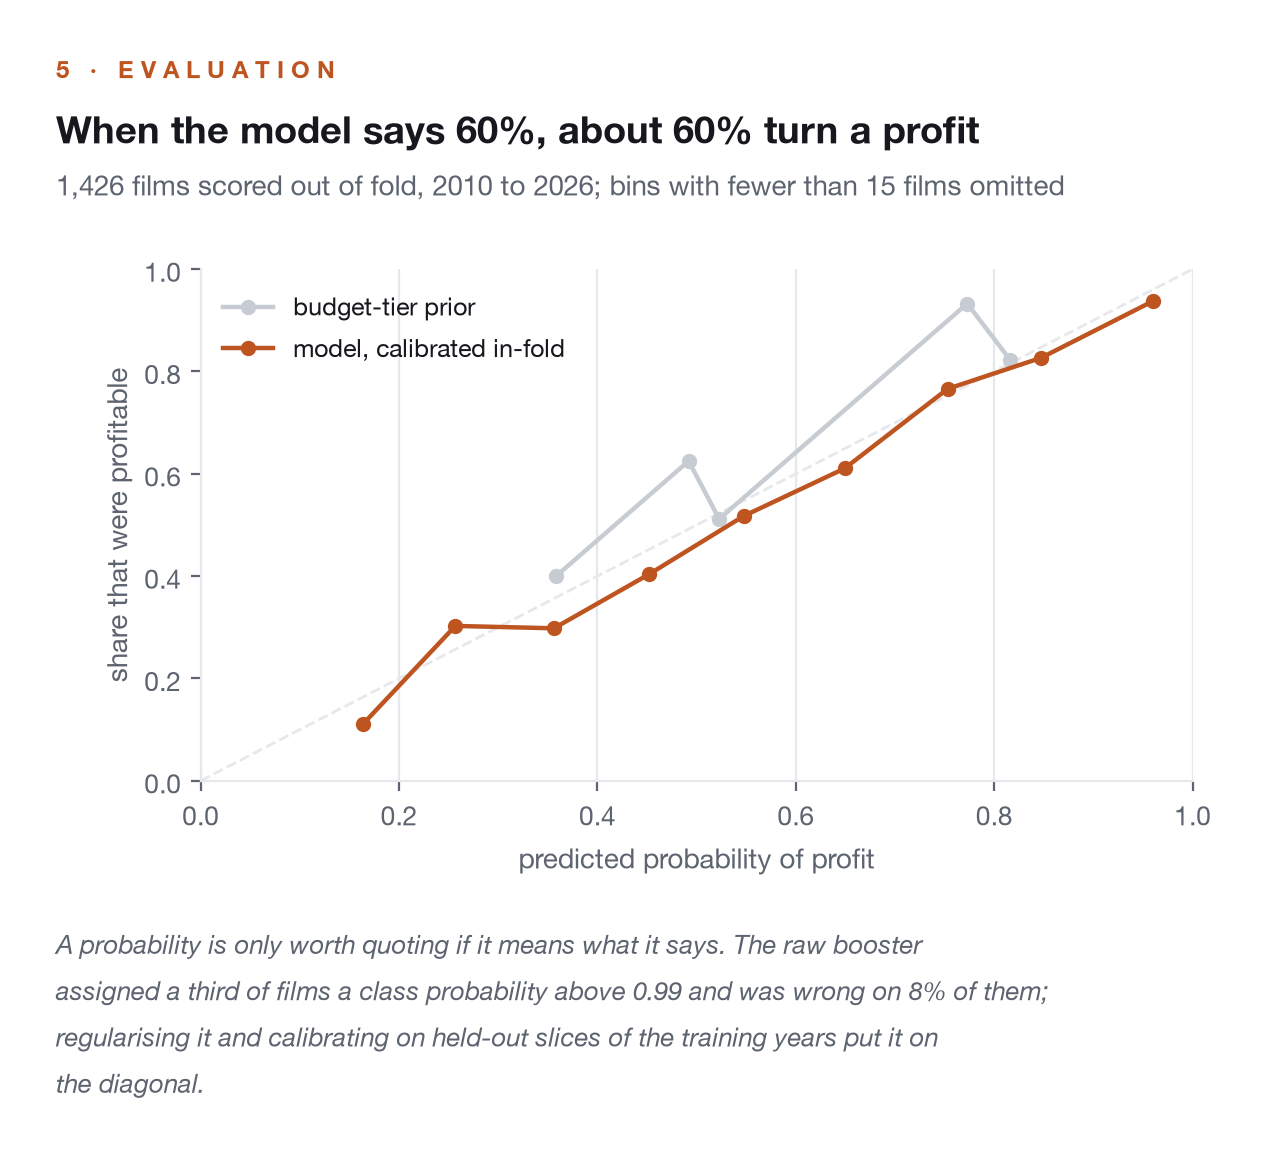

In [30]:
from IPython.display import Image, display as _d
_d(Image(str(ROOT / 'backend/boxoffice/reports/figures/bo-5-reliability.png'), width=720))

## Decision 17: beat the tier, or admit you cannot

Paired per film: the log-loss difference between prior and model, bootstrapped
over films for the interval, with a sign test on which was closer. Reported
per tier because the overall figure is dominated by the tier where the prior
is already excellent, and the tier that matters is the one where it is not.

In [31]:
sig = pd.read_csv(ROOT / 'backend/boxoffice/data/classify_significance.csv')
sig[['slice', 'films', 'logloss_prior', 'logloss_model', 'improvement',
     'ci_lo', 'ci_hi', 'films_model_closer', 'p_sign', 'verdict']].round(4)

,slice,films,logloss_prior,logloss_model,improvement,ci_lo,ci_hi,films_model_closer,p_sign,verdict
0,all,1426,0.7152,0.6518,0.0634,0.0418,0.0843,956,0.0000,model better
1,<$15m,307,0.9529,0.8721,0.0808,0.0366,0.1236,183,0.0009,model better
2,$15-50m,549,0.8428,0.7833,0.0595,0.0208,0.0965,345,0.0000,model better
3,$50m+,570,0.4644,0.4066,0.0579,0.0279,0.0873,428,0.0000,model better


### The headline: which of the sub-$15m films work

The model beats the budget-tier prior in every tier with every interval clear
of zero. That is the first claim in this project that survives at the level of
a single tier rather than pooled across all of them.

In the tier where the prior is weakest and the question matters most, the
model *ranks*. The prior cannot: within a tier in a given year it hands every
film the same number.

In [32]:
small = folds[folds.tier == '<$15m']
q = len(small) // 4
top, bottom = small.nlargest(q, 'p_profit'), small.nsmallest(q, 'p_profit')
pd.DataFrame([
    {'quartile by predicted P(profit)': 'top quarter',    'films': q, 'actually profitable': (top.y == 2).mean()},
    {'quartile by predicted P(profit)': 'bottom quarter', 'films': q, 'actually profitable': (bottom.y == 2).mean()},
    {'quartile by predicted P(profit)': 'tier base rate', 'films': len(small), 'actually profitable': (small.y == 2).mean()},
]).assign(**{'actually profitable': lambda d: d['actually profitable'].map('{:.1%}'.format)})

,quartile by predicted P(profit),films,actually profitable
0,top quarter,76,67.1%
1,bottom quarter,76,22.4%
2,tier base rate,307,40.1%


### The decision curve

Flag a film as not profitable when its predicted P(profit) falls below a
threshold. Where to sit on the curve is a business decision; the gap between
the two lines is what thirty-seven other pre-release facts are worth once the
budget is already known.

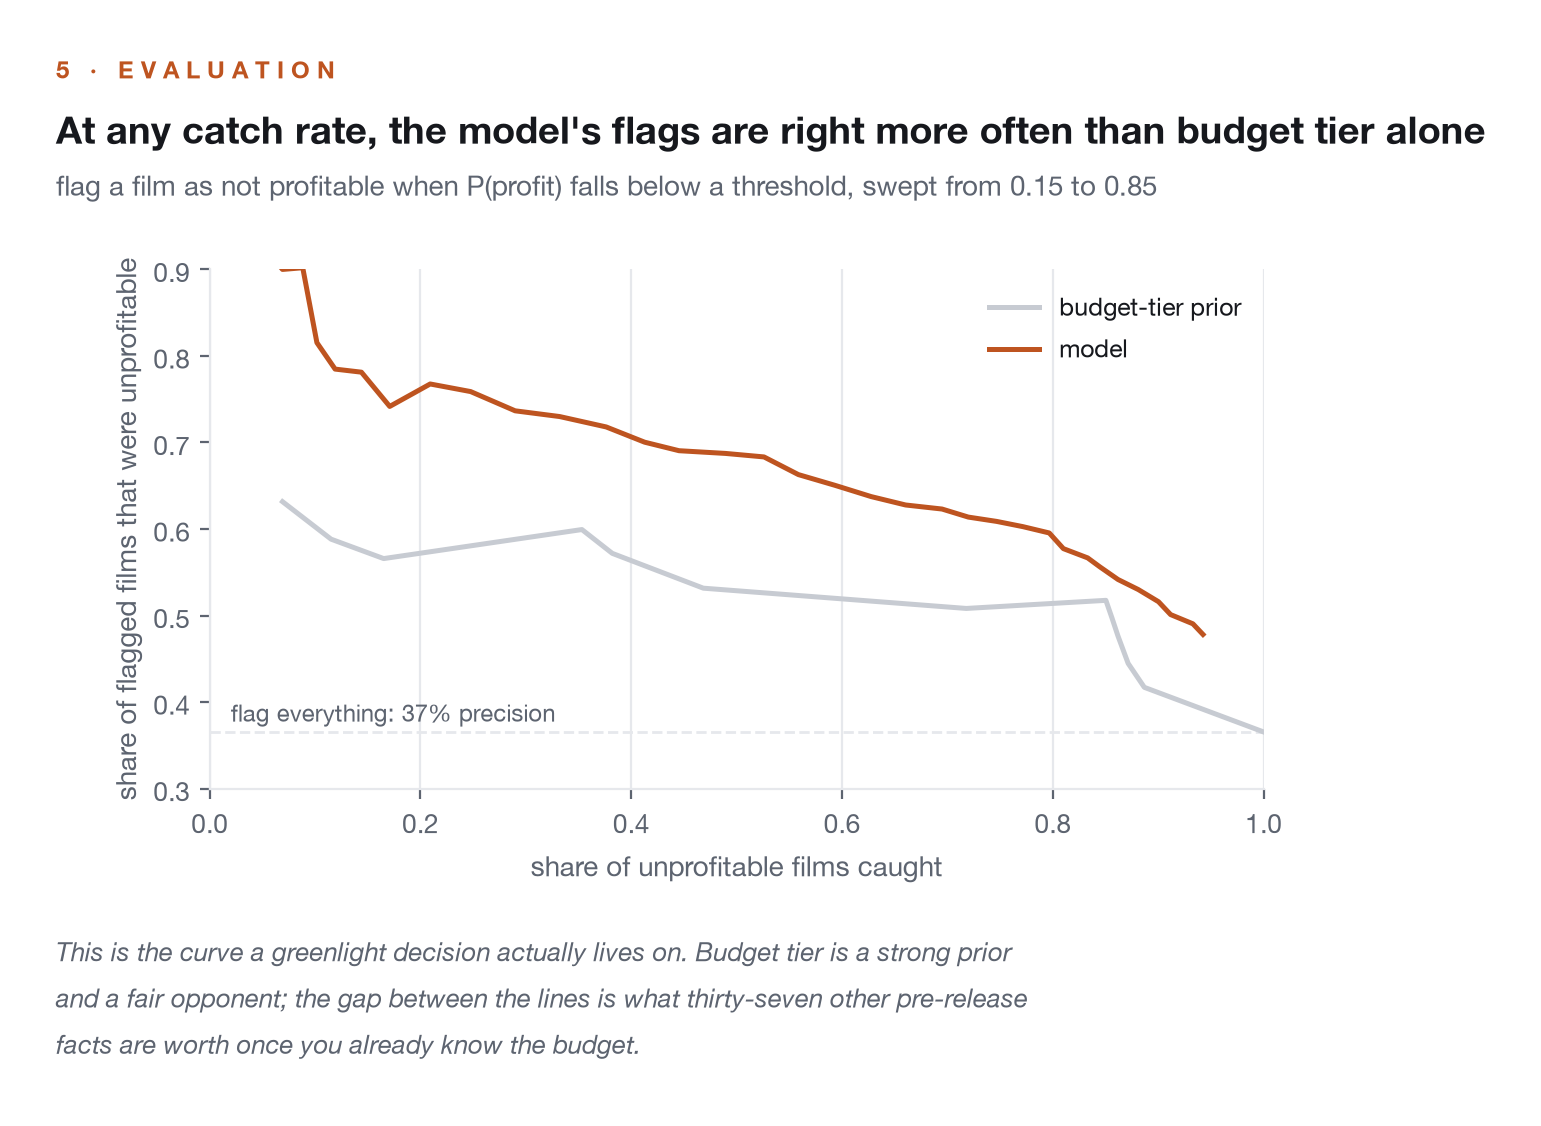

In [33]:
_d(Image(str(ROOT / 'backend/boxoffice/reports/figures/bo-6-decision-curve.png'), width=720))

### What it cannot do

**It never calls a write-off.** Fifty-nine of 1,426 scored films, 4%, and
neither model nor prior ever predicts the class as most likely. The model
separates them three to one on probability but never past the point of a
call. A class that rare on a sample this size is detectable and not
predictable, which is the same limit the regression met from the other side
when it projected nine times actual in the bottom decile.

**Two thousand films is small**, and the sub-$15m result rests on 307 of
them. The direction is not in doubt; the size is approximate.

**"Profitable" means the worldwide gross returned the budget at the multiple
the clustering found.** Prints and advertising, exhibitor splits and ancillary
revenue are in no public dataset. That is the assumption the whole part rests
on, stated rather than assumed.

---
## What is not established

* **2020 breaks.** Both model and baseline collapse. The pandemic severed the
  budget-to-gross relationship and a model trained through 2019 had no way to
  know. That is temporal validation being honest, not a bug.
* **Domestic coverage is 28%** and thinnest in the recent years that matter
  most, so the three-way split above is directional. A daily job is filling it.
* **The sample is studio films.** It will not price a microbudget breakout,
  because the frame excluded films no distributor picked up.
* **No learner is meaningfully better than any other here.** Ridge, a random
  forest and two boosters land within two points of each other, so the error
  that remains is a property of what is knowable before release rather than of
  the estimator. More modelling will not move it; better features, or an
  admission that some of opening weekend is unforecastable, might.
* **Cast contributing nothing may be a sample-size result** rather than a truth
  about stardom. 2,457 films is not many, and prior gross is a crude proxy for
  drawing power.
